In [4]:
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, precision_recall_curve, auc

plt.style.use('seaborn-v0_8-whitegrid')

repo_root = Path.cwd()
if not (repo_root / 'results').exists() and (repo_root.parent / 'results').exists():
    repo_root = repo_root.parent

results_dir = repo_root / 'results'
figures_dir = repo_root / 'figures'
figures_dir.mkdir(exist_ok=True, parents=True)

robust_path = results_dir / 'robust_eval.json'
preds_path = results_dir / 'robust_eval_predictions.npz'

with open(robust_path, 'r') as f:
    robust = json.load(f)
preds = np.load(preds_path, allow_pickle=True)

robust.keys()

dict_keys(['logistic_regression', 'random_forest', 'comparisons', '_runtime_seconds'])

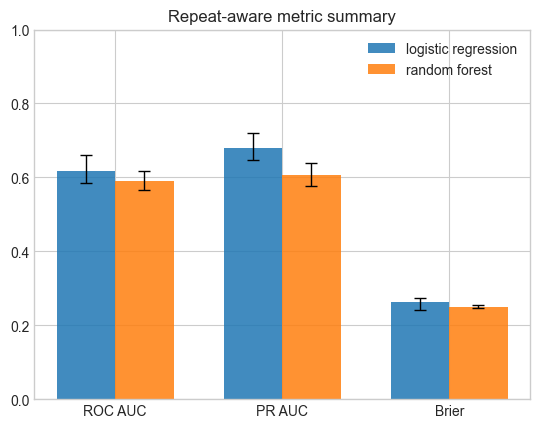

In [5]:
def metric_ci(model_name, metric_name, source='repeat_bootstrap_ci'):
    entry = robust[model_name][source][metric_name]
    return entry['mean'], entry['ci_2.5'], entry['ci_97.5']

def plot_metric_bars(ax):
    metrics = ['roc_auc', 'pr_auc', 'brier']
    labels = ['ROC AUC', 'PR AUC', 'Brier']
    models = ['logistic_regression', 'random_forest']
    colors = ['#1f77b4', '#ff7f0e']
    x = np.arange(len(metrics))
    width = 0.35
    for i, model in enumerate(models):
        means = []
        yerr_low = []
        yerr_high = []
        for m in metrics:
            mean, lo, hi = metric_ci(model, m, 'repeat_bootstrap_ci')
            means.append(mean)
            yerr_low.append(mean - lo)
            yerr_high.append(hi - mean)
        ax.bar(x + (i - 0.5) * width, means, width, label=model.replace('_', ' '), color=colors[i], alpha=0.85, capsize=4)
        ax.errorbar(x + (i - 0.5) * width, means, yerr=[yerr_low, yerr_high], fmt='none', ecolor='black', elinewidth=1, capsize=4)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylim(0, 1)
    ax.set_title('Repeat-aware metric summary')
    ax.legend()

def interp_curve(x, y, grid):
    x = np.asarray(x)
    y = np.asarray(y)
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    x_unique, idx = np.unique(x, return_index=True)
    y = y[idx]
    x = x_unique
    if len(x) < 2:
        return np.full_like(grid, y[0] if len(y) else np.nan, dtype=float)
    return np.interp(grid, x, y, left=y[0], right=y[-1])

def curve_band_from_repeats(y_true, repeat_probs, kind='roc', n_grid=200):
    repeat_probs = np.asarray(repeat_probs)
    if repeat_probs.ndim != 2:
        raise ValueError('repeat_probs must have shape (n_repeats, n_samples)')
    if kind == 'roc':
        grid = np.linspace(0.0, 1.0, n_grid)
        curves = []
        for p in repeat_probs:
            fpr, tpr, _ = roc_curve(y_true, p)
            curves.append(interp_curve(fpr, tpr, grid))
        curves = np.vstack(curves)
        return grid, curves.mean(axis=0), np.percentile(curves, 2.5, axis=0), np.percentile(curves, 97.5, axis=0)
    if kind == 'pr':
        grid = np.linspace(0.0, 1.0, n_grid)
        curves = []
        for p in repeat_probs:
            precision, recall, _ = precision_recall_curve(y_true, p)
            precision = precision[::-1]
            recall = recall[::-1]
            curves.append(interp_curve(recall, precision, grid))
        curves = np.vstack(curves)
        return grid, curves.mean(axis=0), np.percentile(curves, 2.5, axis=0), np.percentile(curves, 97.5, axis=0)
    if kind == 'calibration':
        grid = np.linspace(0.0, 1.0, n_grid)
        curves = []
        for p in repeat_probs:
            frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=10, strategy='quantile')
            curves.append(interp_curve(mean_pred, frac_pos, grid))
        curves = np.vstack(curves)
        return grid, curves.mean(axis=0), np.percentile(curves, 2.5, axis=0), np.percentile(curves, 97.5, axis=0)
    raise ValueError(kind)

def plot_curve_band(ax, y_true, repeat_probs, kind, title, model_label, color):
    grid, mean_y, lo_y, hi_y = curve_band_from_repeats(y_true, repeat_probs, kind=kind)
    ax.plot(grid, mean_y, color=color, label=model_label)
    ax.fill_between(grid, lo_y, hi_y, color=color, alpha=0.2)
    if kind == 'roc':
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
        ax.set_xlabel('False Positive Rate')
        ax.set_ylabel('True Positive Rate')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    elif kind == 'pr':
        prevalence = np.mean(y_true)
        ax.hlines(prevalence, 0, 1, linestyle='--', color='gray', linewidth=1, label='prevalence')
        ax.set_xlabel('Recall')
        ax.set_ylabel('Precision')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    else:
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
        ax.set_xlabel('Mean predicted probability')
        ax.set_ylabel('Observed positive fraction')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    ax.set_title(title)

plot_metric_bars(plt.gca())

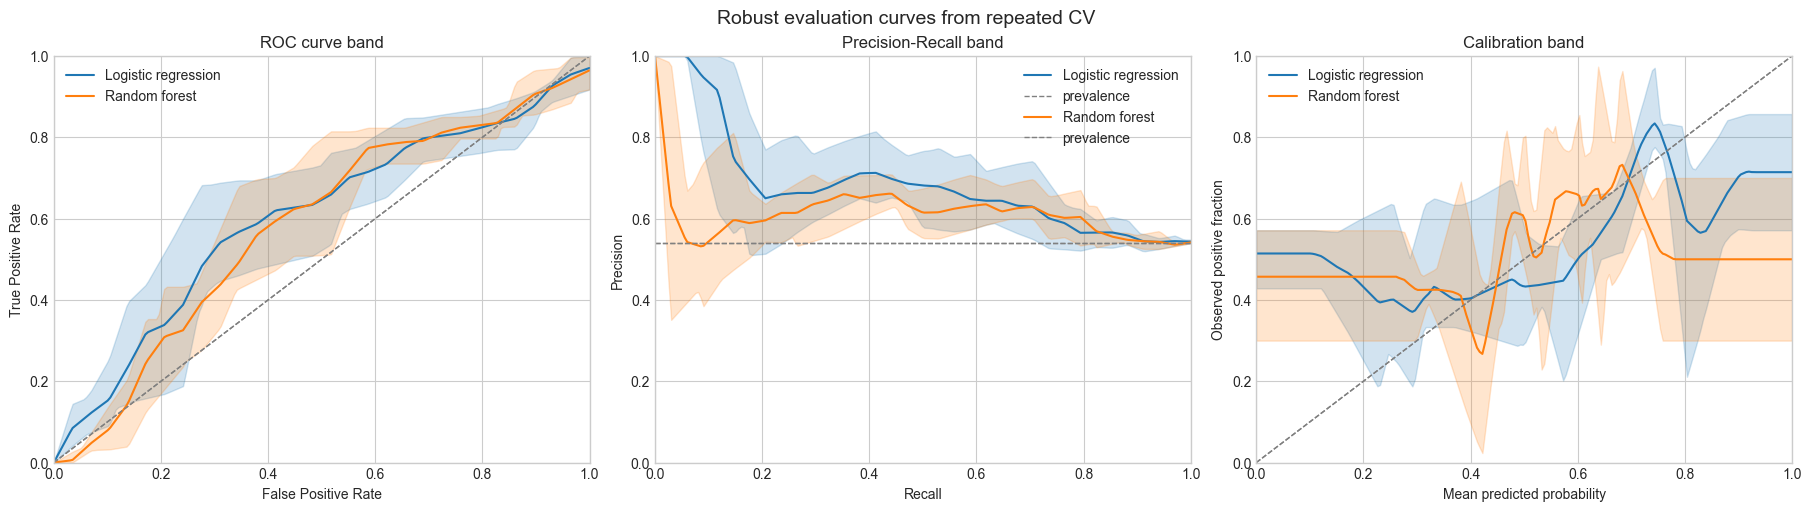

{'auc_1': 0.6146044624746451,
 'auc_2': 0.6252535496957403,
 'auc_diff': -0.010649087221095255,
 'p_value': 0.8663131576357261}

In [6]:
y_lr = preds['logistic_regression_y_true']
p_lr = preds['logistic_regression_repeat_probs']
y_rf = preds['random_forest_y_true']
p_rf = preds['random_forest_repeat_probs']

fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
plot_curve_band(axes[0], y_lr, p_lr, 'roc', 'ROC curve band', 'Logistic regression', '#1f77b4')
plot_curve_band(axes[0], y_rf, p_rf, 'roc', 'ROC curve band', 'Random forest', '#ff7f0e')
axes[0].legend()

plot_curve_band(axes[1], y_lr, p_lr, 'pr', 'Precision-Recall band', 'Logistic regression', '#1f77b4')
plot_curve_band(axes[1], y_rf, p_rf, 'pr', 'Precision-Recall band', 'Random forest', '#ff7f0e')
axes[1].legend()

plot_curve_band(axes[2], y_lr, p_lr, 'calibration', 'Calibration band', 'Logistic regression', '#1f77b4')
plot_curve_band(axes[2], y_rf, p_rf, 'calibration', 'Calibration band', 'Random forest', '#ff7f0e')
axes[2].legend()

fig.suptitle('Robust evaluation curves from repeated CV', fontsize=14)
fig.savefig(figures_dir / 'robust_eval_curves.png', dpi=200, bbox_inches='tight')
plt.show()

comp = robust.get('comparisons', {}).get('logistic_regression_vs_random_forest', {})
comp

## Interpretation

- Repeat-aware confidence intervals are narrower than sample-bootstrap intervals, which is expected when uncertainty is summarized over repeated CV runs.
- The DeLong test in `robust_eval.json` compares pooled mean probabilities from both models.
- The generated figure `figures/robust_eval_curves.png` can be used directly in the report.

Next step: add an external ECG dataset loader for PTBDB/CPSC validation.